In [37]:
import numpy as np
import matplotlib.pyplot as plt
import time

import scipy.sparse as sp
import scipy.sparse.linalg as spla

plt.rcParams['figure.figsize'] = [15, 5]
np.random.seed(42)

## Helper: Gauss–Seidel solver

Solves the discrete Poisson equation  
$$4u_{i,j} - u_{i-1,j} - u_{i+1,j} - u_{i,j-1} - u_{i,j+1} = b_{i,j}$$  
with Dirichlet boundary conditions by iterating until convergence.

In [38]:
def gauss_seidel(b, boundary, mask, max_iter=2000, tol=1e-4):
    u = boundary.copy().astype(np.float64)
    for it in range(max_iter):
        u_old = u.copy()
        u[1:-1, 1:-1] = np.where(
            mask[1:-1, 1:-1],
            (b[1:-1, 1:-1]
             + u[:-2, 1:-1] + u[2:, 1:-1]
             + u[1:-1, :-2] + u[1:-1, 2:]) / 4.0,
            u[1:-1, 1:-1]
        )
        if np.max(np.abs(u - u_old)) < tol:
            break
    return u

## Helper: sparse Poisson matrix builder

In [39]:
def build_poisson_system(b, boundary, mask):
    H, W = b.shape
    idx = np.full((H, W), -1, dtype=int)
    interior = np.argwhere(mask)
    for k, (i, j) in enumerate(interior):
        idx[i, j] = k
    N = len(interior)

    rows, cols, vals = [], [], []
    rhs = np.zeros(N)

    for k, (i, j) in enumerate(interior):
        rows.append(k); cols.append(k); vals.append(4.0)
        rhs[k] = b[i, j]
        for di, dj in [(-1,0),(1,0),(0,-1),(0,1)]:
            ni, nj = i+di, j+dj
            if mask[ni, nj]:
                rows.append(k); cols.append(idx[ni, nj]); vals.append(-1.0)
            else:
                rhs[k] += boundary[ni, nj]

    A = sp.csr_matrix((vals, (rows, cols)), shape=(N, N))
    return A, rhs, interior, idx


def sparse_solve(b, boundary, mask):
    A, rhs, interior, idx = build_poisson_system(b, boundary, mask)
    x = spla.spsolve(A, rhs)
    u = boundary.copy().astype(np.float64)
    for k, (i, j) in enumerate(interior):
        u[i, j] = x[k]
    return u

---
## Task 1: Image Reconstruction from Gradient Field

Given the gradient field $(g_x, g_y)$ of an image, reconstruct the original image by solving:
$$\nabla^2 u = \text{div}(g_x, g_y)$$

In [40]:
H, W = 256, 256
xx, yy = np.meshgrid(np.linspace(-1, 1, W), np.linspace(-1, 1, H))
r = np.sqrt(xx**2 + yy**2)
theta = np.arctan2(yy, xx)

# Радіальний sunburst — більш наглядний, має чіткі радіальні смуги
original = (np.sin(12 * theta + 9 * np.pi * r) * np.exp(-r * 0.5) + 1.0) * 0.5
original = np.clip(original, 0, 1)
original = (original * 255).astype(np.uint8).astype(np.float64)

gx = np.zeros_like(original)
gy = np.zeros_like(original)
gx[:, :-1] = np.diff(original, axis=1)
gy[:-1, :] = np.diff(original, axis=0)

div_gx = np.zeros_like(gx)
div_gx[:, 1:] = np.diff(gx, axis=1)
div_gy = np.zeros_like(gy)
div_gy[1:, :] = np.diff(gy, axis=0)

b_reconstruct = -(div_gx + div_gy)

# Граничні умови — лише крайові пікселі; внутрішні починають з 0
# щоб GS справді сходився з нуля, а не з готового розв'язку
boundary_r = np.zeros_like(original)
boundary_r[0, :]  = original[0, :]
boundary_r[-1, :] = original[-1, :]
boundary_r[:, 0]  = original[:, 0]
boundary_r[:, -1] = original[:, -1]

mask_r = np.zeros((H, W), dtype=bool)
mask_r[1:-1, 1:-1] = True

print(f'Image size: {H}x{W},  interior pixels: {mask_r.sum()}')

Image size: 256x256,  interior pixels: 64516


In [41]:
t0 = time.perf_counter()
rec_gs = gauss_seidel(b_reconstruct, boundary_r, mask_r, max_iter=8000, tol=1e-5)
t_gs_reconstruct = time.perf_counter() - t0
print(f'Gauss-Seidel:  {t_gs_reconstruct:.3f} s')

t0 = time.perf_counter()
rec_sp = sparse_solve(b_reconstruct, boundary_r, mask_r)
t_sp_reconstruct = time.perf_counter() - t0
print(f'Sparse solve:  {t_sp_reconstruct:.3f} s')

Gauss-Seidel:  1.571 s
Sparse solve:  0.323 s


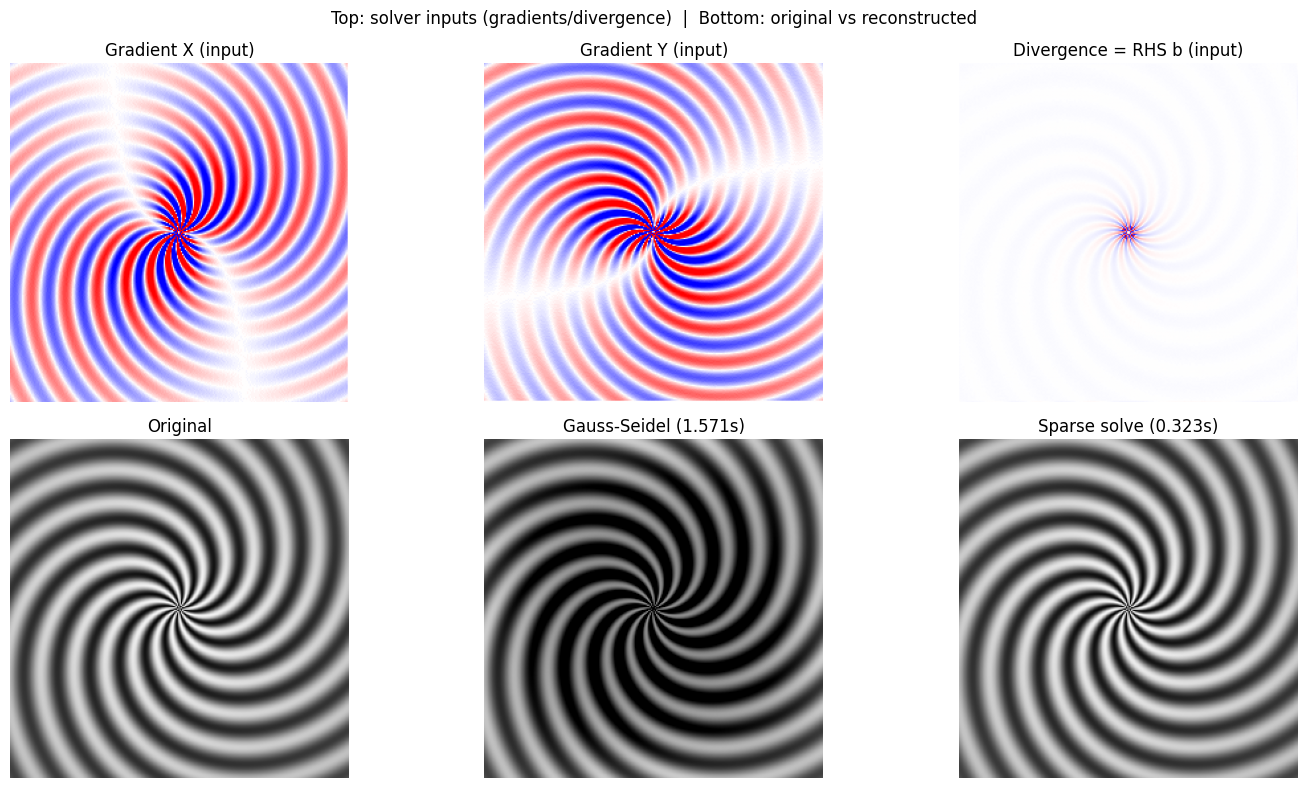

Max error  Gauss-Seidel: 105.6187
Max error  Sparse solve: 0.0000


In [42]:
err_gs = np.abs(rec_gs - original)
err_sp = np.abs(rec_sp - original)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

axes[0, 0].imshow(gx, cmap='bwr', vmin=-30, vmax=30)
axes[0, 0].set_title('Gradient X (input)'); axes[0, 0].axis('off')

axes[0, 1].imshow(gy, cmap='bwr', vmin=-30, vmax=30)
axes[0, 1].set_title('Gradient Y (input)'); axes[0, 1].axis('off')

axes[0, 2].imshow(b_reconstruct, cmap='bwr')
axes[0, 2].set_title('Divergence = RHS b (input)'); axes[0, 2].axis('off')

axes[1, 0].imshow(original, cmap='gray', vmin=0, vmax=255)
axes[1, 0].set_title('Original'); axes[1, 0].axis('off')

axes[1, 1].imshow(rec_gs, cmap='gray', vmin=0, vmax=255)
axes[1, 1].set_title(f'Gauss-Seidel ({t_gs_reconstruct:.3f}s)'); axes[1, 1].axis('off')

axes[1, 2].imshow(rec_sp, cmap='gray', vmin=0, vmax=255)
axes[1, 2].set_title(f'Sparse solve ({t_sp_reconstruct:.3f}s)'); axes[1, 2].axis('off')

plt.suptitle('Top: solver inputs (gradients/divergence)  |  Bottom: original vs reconstructed')
plt.tight_layout()
plt.show()

print(f'Max error  Gauss-Seidel: {err_gs.max():.4f}')
print(f'Max error  Sparse solve: {err_sp.max():.4f}')

---
## Task 2: Seamless Image Cloning (Poisson Blending)

A source patch is blended seamlessly into a target image by solving:
$$\nabla^2 u = \nabla^2 f_s  \quad \text{inside mask}$$
$$u = f_t \quad \text{on boundary}$$
where $f_s$ is the source and $f_t$ is the target image.

In [43]:
H, W = 200, 300

xx, yy = np.meshgrid(np.linspace(0,1,W), np.linspace(0,1,H))
target_gray = (xx * 200 + 30).astype(np.float64)

cx, cy, r = W//2, H//2, 50
dist = np.sqrt((xx*W - cx)**2 + (yy*H - cy)**2)
source_gray = (np.sin(8*np.pi*xx) * np.cos(6*np.pi*yy) * 80 + 128).astype(np.float64)

mask_blend = (dist < r)
mask_blend[0, :] = mask_blend[-1, :] = mask_blend[:, 0] = mask_blend[:, -1] = False

def laplacian(img):
    lap = np.zeros_like(img)
    lap[1:-1,1:-1] = (img[:-2,1:-1] + img[2:,1:-1]
                     + img[1:-1,:-2] + img[1:-1,2:]
                     - 4*img[1:-1,1:-1])
    return lap

b_blend = -laplacian(source_gray)
boundary_b = target_gray.copy()

print(f'Blend image: {H}x{W},  mask pixels: {mask_blend.sum()}')

Blend image: 200x300,  mask pixels: 7796


In [44]:
naive = target_gray.copy()
naive[mask_blend] = source_gray[mask_blend]

t0 = time.perf_counter()
blend_gs = gauss_seidel(b_blend, boundary_b, mask_blend, max_iter=3000, tol=1e-4)
t_gs_blend = time.perf_counter() - t0
print(f'Gauss-Seidel:  {t_gs_blend:.3f} s')

t0 = time.perf_counter()
blend_sp = sparse_solve(b_blend, boundary_b, mask_blend)
t_sp_blend = time.perf_counter() - t0
print(f'Sparse solve:  {t_sp_blend:.3f} s')

Gauss-Seidel:  0.545 s
Sparse solve:  0.035 s


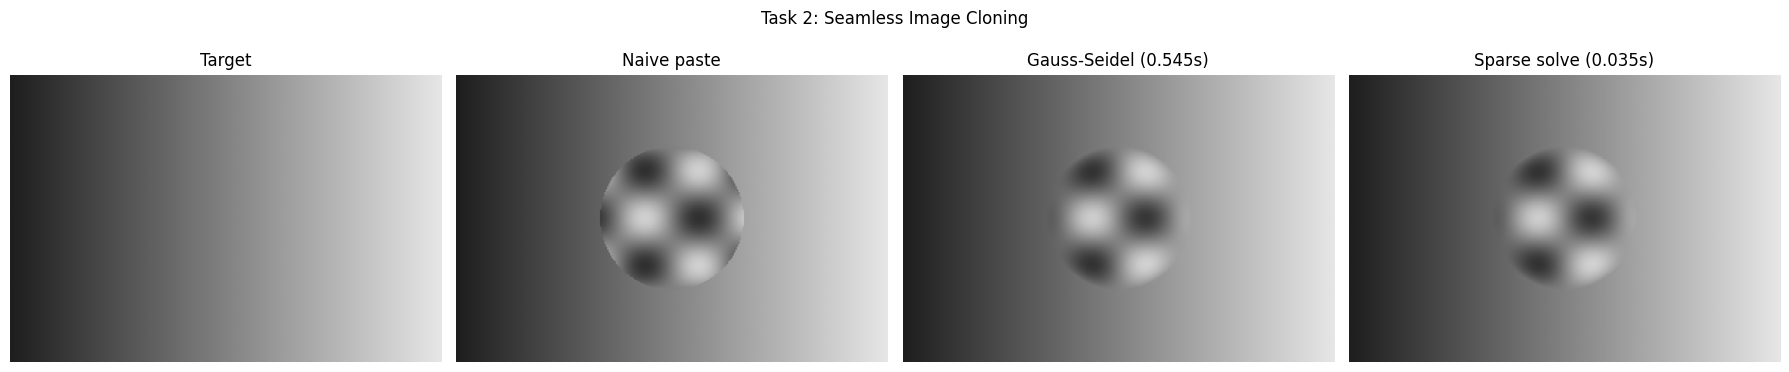

In [45]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
vmin, vmax = 0, 255
axes[0].imshow(target_gray, cmap='gray', vmin=vmin, vmax=vmax)
axes[0].set_title('Target'); axes[0].axis('off')
axes[1].imshow(naive, cmap='gray', vmin=vmin, vmax=vmax)
axes[1].set_title('Naive paste'); axes[1].axis('off')
axes[2].imshow(np.clip(blend_gs, 0, 255), cmap='gray', vmin=vmin, vmax=vmax)
axes[2].set_title(f'Gauss-Seidel ({t_gs_blend:.3f}s)'); axes[2].axis('off')
axes[3].imshow(np.clip(blend_sp, 0, 255), cmap='gray', vmin=vmin, vmax=vmax)
axes[3].set_title(f'Sparse solve ({t_sp_blend:.3f}s)'); axes[3].axis('off')
plt.suptitle('Task 2: Seamless Image Cloning')
plt.tight_layout()
plt.show()

---
## Timing Comparison: Scaling with Image Size

Benchmark both methods across several image sizes to compare performance.

In [46]:
sizes = [32, 64, 96, 128, 160, 192]
times_gs = []
times_sp = []
errors_gs = []

for s in sizes:
    xx_, yy_ = np.meshgrid(np.linspace(0,1,s), np.linspace(0,1,s))
    img = (np.sin(4*np.pi*xx_) * np.cos(3*np.pi*yy_) * 127 + 128)

    gx_ = np.zeros_like(img); gx_[:, :-1] = np.diff(img, axis=1)
    gy_ = np.zeros_like(img); gy_[:-1, :] = np.diff(img, axis=0)
    div_x = np.zeros_like(gx_); div_x[:, 1:] = np.diff(gx_, axis=1)
    div_y = np.zeros_like(gy_); div_y[1:, :] = np.diff(gy_, axis=0)
    b_ = -(div_x + div_y)

    bnd = np.zeros_like(img)
    bnd[0, :]  = img[0, :]
    bnd[-1, :] = img[-1, :]
    bnd[:, 0]  = img[:, 0]
    bnd[:, -1] = img[:, -1]

    msk = np.zeros((s, s), dtype=bool)
    msk[1:-1, 1:-1] = True

    t0 = time.perf_counter()
    u_sp = sparse_solve(b_, bnd, msk)
    times_sp.append(time.perf_counter() - t0)

    t0 = time.perf_counter()
    u_gs = gauss_seidel(b_, bnd, msk, max_iter=5000, tol=1e-5)
    times_gs.append(time.perf_counter() - t0)

    err = np.max(np.abs(u_gs - u_sp))
    errors_gs.append(err)

    print(f's={s:3d}  GS={times_gs[-1]:.3f}s  SP={times_sp[-1]:.4f}s  GS_err={err:.4f}')

s= 32  GS=0.027s  SP=0.0040s  GS_err=0.0019
s= 64  GS=0.109s  SP=0.0156s  GS_err=0.4127
s= 96  GS=0.176s  SP=0.0383s  GS_err=13.4668
s=128  GS=0.277s  SP=0.0699s  GS_err=44.8577
s=160  GS=0.399s  SP=0.1133s  GS_err=77.1292
s=192  GS=0.580s  SP=0.1670s  GS_err=100.8629


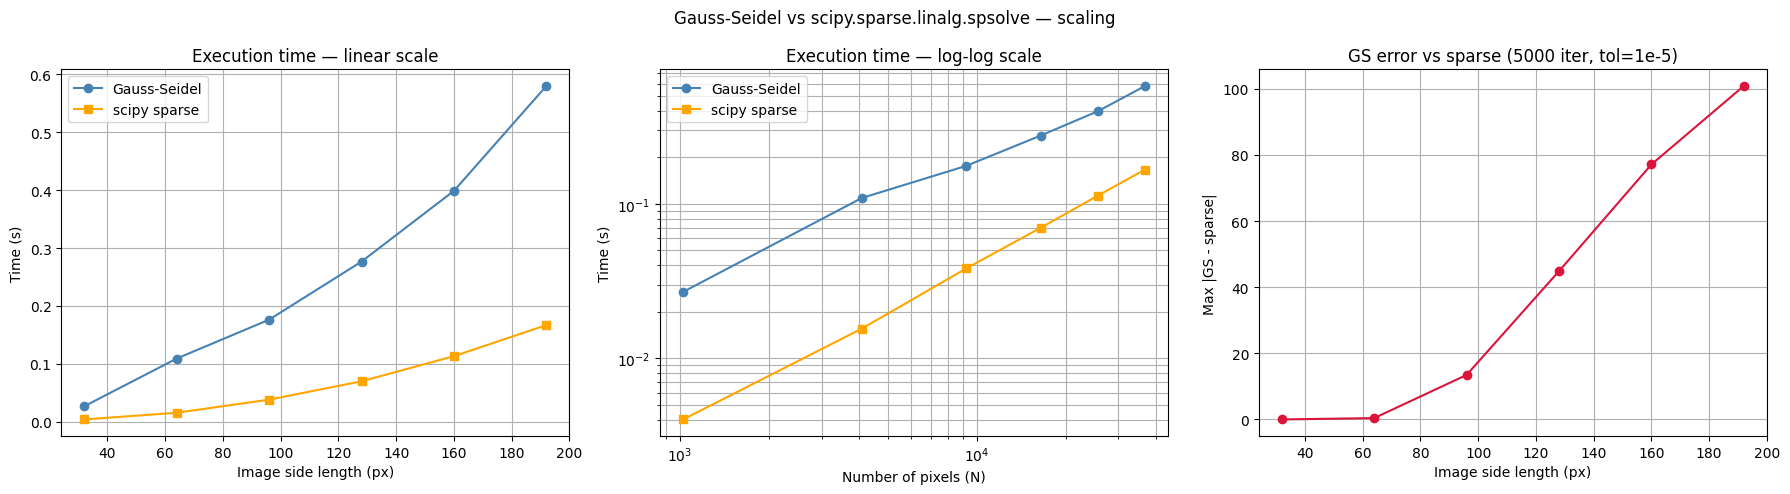

In [47]:
npixels = [s*s for s in sizes]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# linear scale
axes[0].plot(sizes, times_gs, 'o-', label='Gauss-Seidel', color='steelblue')
axes[0].plot(sizes, times_sp, 's-', label='scipy sparse', color='orange')
axes[0].set_xlabel('Image side length (px)')
axes[0].set_ylabel('Time (s)')
axes[0].set_title('Execution time — linear scale')
axes[0].legend()
axes[0].grid(True)

# log scale
axes[1].plot(npixels, times_gs, 'o-', label='Gauss-Seidel', color='steelblue')
axes[1].plot(npixels, times_sp, 's-', label='scipy sparse', color='orange')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('Number of pixels (N)')
axes[1].set_ylabel('Time (s)')
axes[1].set_title('Execution time — log-log scale')
axes[1].legend()
axes[1].grid(True, which='both')

# GS max error vs sparse (точність)
axes[2].plot(sizes, errors_gs, 'o-', color='crimson')
axes[2].set_xlabel('Image side length (px)')
axes[2].set_ylabel('Max |GS - sparse|')
axes[2].set_title('GS error vs sparse (5000 iter, tol=1e-5)')
axes[2].grid(True)

plt.suptitle('Gauss-Seidel vs scipy.sparse.linalg.spsolve — scaling')
plt.tight_layout()
plt.show()

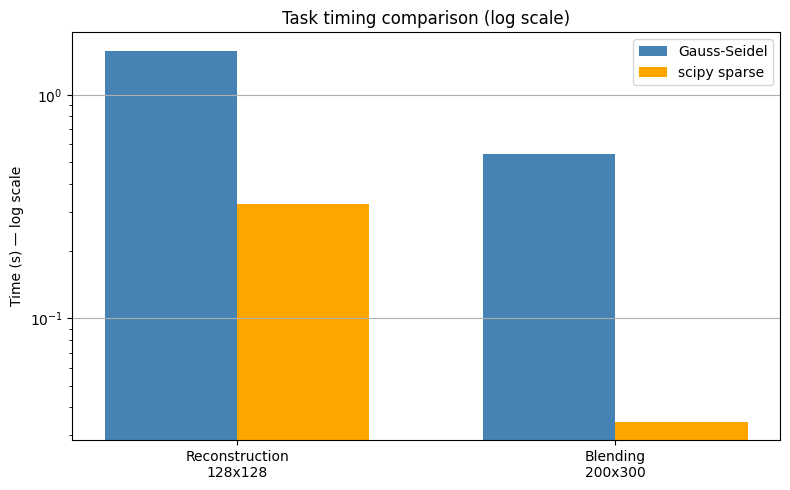


Speedup (GS/sparse):
  Reconstruction: 4.9x
  Blending:       15.7x


In [48]:
# bar chart for the two specific tasks
fig, ax = plt.subplots(figsize=(8, 5))
tasks = ['Reconstruction\n128x128', 'Blending\n200x300']
gs_times = [t_gs_reconstruct, t_gs_blend]
sp_times = [t_sp_reconstruct, t_sp_blend]
x = np.arange(len(tasks))
w = 0.35
ax.bar(x - w/2, gs_times, w, label='Gauss-Seidel', color='steelblue')
ax.bar(x + w/2, sp_times, w, label='scipy sparse', color='orange')
ax.set_yscale('log')
ax.set_ylabel('Time (s) — log scale')
ax.set_title('Task timing comparison (log scale)')
ax.set_xticks(x); ax.set_xticklabels(tasks)
ax.legend()
ax.grid(True, axis='y')
plt.tight_layout()
plt.show()

print(f'\nSpeedup (GS/sparse):')
print(f'  Reconstruction: {t_gs_reconstruct/t_sp_reconstruct:.1f}x')
print(f'  Blending:       {t_gs_blend/t_sp_blend:.1f}x')